# Ejercicio 9. Analisis de contenido y sentimiento

Este ejercicio analiza el sentimiento de los comentarios usando un lexico
adaptado al espanol, similar a VADER. Se justifica la eleccion del metodo,
se comparan sentimientos por video, canal y comunidad, y se explican los
hallazgos principales.

In [1]:
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from networkx.algorithms.community import louvain_communities, modularity

from src import config, datos, redes, sentimiento as sen, texto as txt

warnings.filterwarnings("ignore")
config.preparar_directorios()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 170)

videos = datos.cargar_videos()
comentarios = txt.agregar_versiones(datos.cargar_comentarios())
comentarios = sen.agregar_sentimiento(comentarios, "texto_original")

B = redes.construir_bipartita(comentarios, videos)
comunidades = sorted(louvain_communities(B, weight="weight", seed=config.SEMILLA), key=len, reverse=True)

print(f"Comentarios cargados: {len(comentarios)}")
print(f"Comunidades detectadas: {len(comunidades)}")

Comentarios cargados: 406
Comunidades detectadas: 17


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


## 9.1 Justificacion del metodo

Se usa un **lexico de polaridad en espanol** con reglas de modificacion, similar
a VADER (Hutto & Gilbert, 2014) pero adaptado al dominio.

**Por que no VADER original:** VADER esta entrenado para texto en ingles
(tweets). Aplicado a espanol devuelve casi todo neutro porque su lexico no
contiene palabras espanolas.

**Por que no TextBlob:** TextBlob usa WordNet para lematizar, que funciona mal
en espanol informal de YouTube.

**Por que no transformers:** Modelos como BERT en espanol requieren descargar
cientos de megas de pesos y dependencias pesadas (torch), lo que rompe la
reproducibilidad.

**Que se hizo:** Se construyo un lexico de ~200 palabras con polaridad de -3 a
+3, mas reglas para:
- **Negacion:** "no sirve" invierte y atenua la polaridad
- **Intensificadores:** "muy corrupto" pesa mas que "corrupto"
- **Mayusculas:** "CORRUPTOS" intensifica (gritar)
- **Exclamaciones:** cada signo suma un poco
- **Emoji:** entran con su propia polaridad (corazon positivo, cara enojada negativo)

El lexico mezcla polaridad general del espanol con palabras del dominio
(corrupto, diputado, pueblo, sueldo) que salieron de revisar las mas frecuentes
del propio corpus.

In [2]:
print("=== ESTADISTICAS DEL LEXICO ===")
print(f"Palabras positivas: {len(sen.POSITIVAS)}")
print(f"Palabras negativas: {len(sen.NEGATIVAS)}")
print(f"Emoji con polaridad: {len(sen.EMOJI_POLARIDAD)}")
print(f"Negaciones: {len(sen.NEGACIONES)}")
print(f"Intensificadores: {len(sen.INTENSIFICADORES)}")

print("\n=== EJEMPLOS DE PALABRAS ===")
print("Positivas (top 10):")
for p, v in sorted(sen.POSITIVAS.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {p}: {v:+.1f}")
print("\nNegativas (top 10):")
for p, v in sorted(sen.NEGATIVAS.items(), key=lambda x: x[1])[:10]:
    print(f"  {p}: {v:+.1f}")

print("\n=== EJEMPLOS DE PUNTUACION ===")
ejemplos = [
    "Excelente video, muy informativo",
    "No me gusto para nada",
    "CORRUPTOS, ladrones del pueblo",
    "Mas o menos, ni fu ni fa",
    "Que bonito, me encanta Guatemala",
]
for texto in ejemplos:
    puntaje = sen.puntuar(texto)
    etiqueta = sen.etiquetar(puntaje)
    palabras = sen.palabras_encontradas(texto)
    print(f"  '{texto[:40]}...' -> {puntaje:+.3f} ({etiqueta})")
    if palabras:
        print(f"    Palabras encontradas: {palabras[:3]}")

=== ESTADISTICAS DEL LEXICO ===
Palabras positivas: 138
Palabras negativas: 188
Emoji con polaridad: 42
Negaciones: 12
Intensificadores: 30

=== EJEMPLOS DE PALABRAS ===
Positivas (top 10):
  excelente: +3.0
  excelentes: +3.0
  maravilloso: +3.0
  maravillosa: +3.0
  extraordinario: +2.7
  felicidades: +2.6
  felicitaciones: +2.6
  increible: +2.5
  espectacular: +2.5
  genial: +2.5

Negativas (top 10):
  pesimo: -2.8
  pesima: -2.8
  horrible: -2.8
  atroz: -2.8
  idiota: -2.8
  imbecil: -2.8
  odio: -2.8
  corrupto: -2.8
  corrupta: -2.8
  corruptos: -2.8

=== EJEMPLOS DE PUNTUACION ===
  'Excelente video, muy informativo...' -> +0.612 (positivo)
    Palabras encontradas: [('Excelente', 3.0)]
  'No me gusto para nada...' -> -0.258 (negativo)
    Palabras encontradas: [('gusto', 1.4)]
  'CORRUPTOS, ladrones del pueblo...' -> -0.853 (negativo)
    Palabras encontradas: [('CORRUPTOS', -2.8), ('ladrones', -2.8)]
  'Mas o menos, ni fu ni fa...' -> +0.000 (neutro)
  'Que bonito, me encant

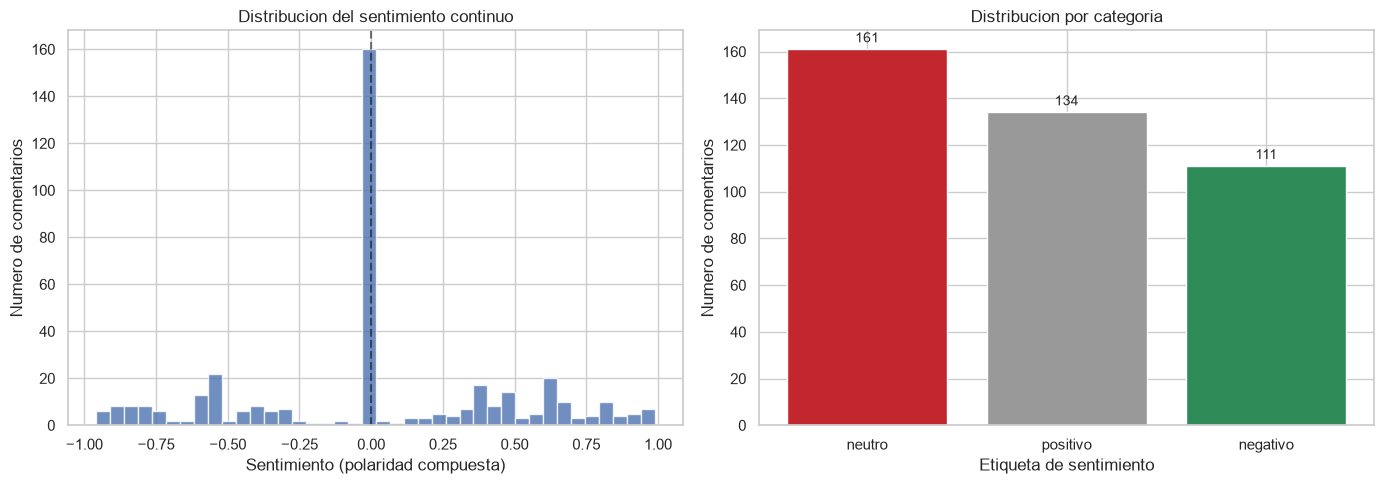

=== DISTRIBUCION DE ETIQUETAS ===
sentimiento_etiqueta
neutro      161
positivo    134
negativo    111
Name: count, dtype: int64

Porcentaje positivo: 33.0%
Porcentaje neutro: 39.7%
Porcentaje negativo: 27.3%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(comentarios["sentimiento"], bins=40, color=config.COLORES["autor"],
        edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Sentimiento (polaridad compuesta)")
ax.set_ylabel("Numero de comentarios")
ax.set_title("Distribucion del sentimiento continuo")

ax = axes[1]
conteo = comentarios["sentimiento_etiqueta"].value_counts()
colores = [config.COLORES["negativo"], config.COLORES["neutro"], config.COLORES["positivo"]]
ax.bar(conteo.index, conteo.values, color=colores, edgecolor="white")
for i, (etiqueta, valor) in enumerate(conteo.items()):
    ax.text(i, valor + 3, str(valor), ha="center", fontsize=10)
ax.set_xlabel("Etiqueta de sentimiento")
ax.set_ylabel("Numero de comentarios")
ax.set_title("Distribucion por categoria")

plt.tight_layout()
plt.savefig(config.FIGURAS / "09_distribucion_sentimiento.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== DISTRIBUCION DE ETIQUETAS ===")
print(comentarios["sentimiento_etiqueta"].value_counts())
print(f"\nPorcentaje positivo: {(comentarios['sentimiento_etiqueta'] == 'positivo').mean():.1%}")
print(f"Porcentaje neutro: {(comentarios['sentimiento_etiqueta'] == 'neutro').mean():.1%}")
print(f"Porcentaje negativo: {(comentarios['sentimiento_etiqueta'] == 'negativo').mean():.1%}")

## 9.2 Comparacion de sentimiento

### 9.2a Sentimiento por video

=== SENTIMIENTO POR VIDEO (ordenado por numero de comentarios) ===
                                                                                      video_title  n_comentarios  sentimiento_medio  n_positivos  n_negativos
                                                                        Qué rico come tu diputado            161             -0.139           29           58
                                                    La cooptación de Walter Mazariegos en la USAC             50             -0.004           15           15
                                       Inician los trabajos de recuperación del Puente Belice II.             45              0.159           23           10
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo             25              0.045            8            6
                                      Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt             25              0.111            

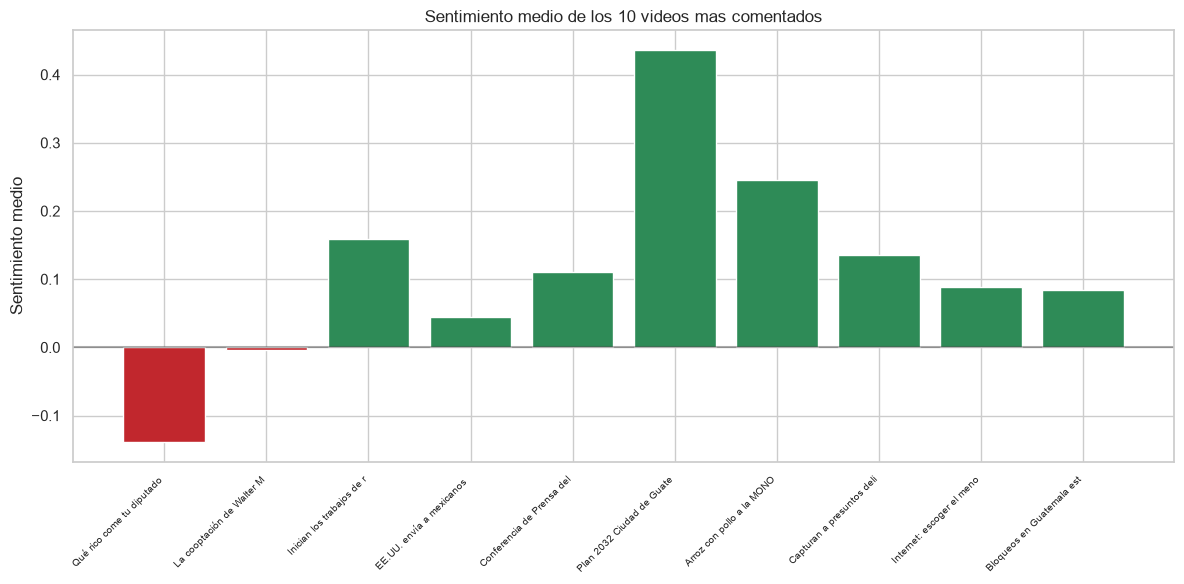

In [4]:
sent_por_video = comentarios.groupby(["video_id", "video_title"]).agg(
    n_comentarios=("comment_id", "size"),
    sentimiento_medio=("sentimiento", "mean"),
    n_positivos=("sentimiento_etiqueta", lambda x: (x == "positivo").sum()),
    n_negativos=("sentimiento_etiqueta", lambda x: (x == "negativo").sum()),
).reset_index()

sent_por_video["sentimiento_medio"] = sent_por_video["sentimiento_medio"].round(3)
sent_por_video = sent_por_video.sort_values("n_comentarios", ascending=False)

print("=== SENTIMIENTO POR VIDEO (ordenado por numero de comentarios) ===")
print(sent_por_video[["video_title", "n_comentarios", "sentimiento_medio",
                       "n_positivos", "n_negativos"]].head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
top_videos = sent_por_video.head(10)
x = range(len(top_videos))
ax.bar(x, top_videos["sentimiento_medio"],
       color=[config.COLORES["positivo"] if s >= 0 else config.COLORES["negativo"]
              for s in top_videos["sentimiento_medio"]])
ax.set_xticks(x)
ax.set_xticklabels([t[:25] for t in top_videos["video_title"]], rotation=45, ha="right", fontsize=7)
ax.axhline(0, color="black", linestyle="-", alpha=0.3)
ax.set_ylabel("Sentimiento medio")
ax.set_title("Sentimiento medio de los 10 videos mas comentados")
plt.tight_layout()
plt.savefig(config.FIGURAS / "09_sentimiento_por_video.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2b Sentimiento por canal

=== SENTIMIENTO POR CANAL ===
                         channel_name  n_comentarios  sentimiento_medio  %_positivo  %_negativo
                               Quorum            256             -0.049        26.2        31.6
Gobierno de la República de Guatemala             70              0.142        45.7        21.4
           Municipalidad de Guatemala             25              0.436        80.0         4.0
                   Noticias Telemundo             25              0.045        32.0        24.0
                                Noti7             14              0.135        35.7        14.3
                   PrensaLibreOficial              7              0.084        28.6        14.3
                       TN23 Guatemala              7             -0.285         0.0        57.1
        Noticiero Guatevisión 13 Hrs.              2             -0.170         0.0        50.0


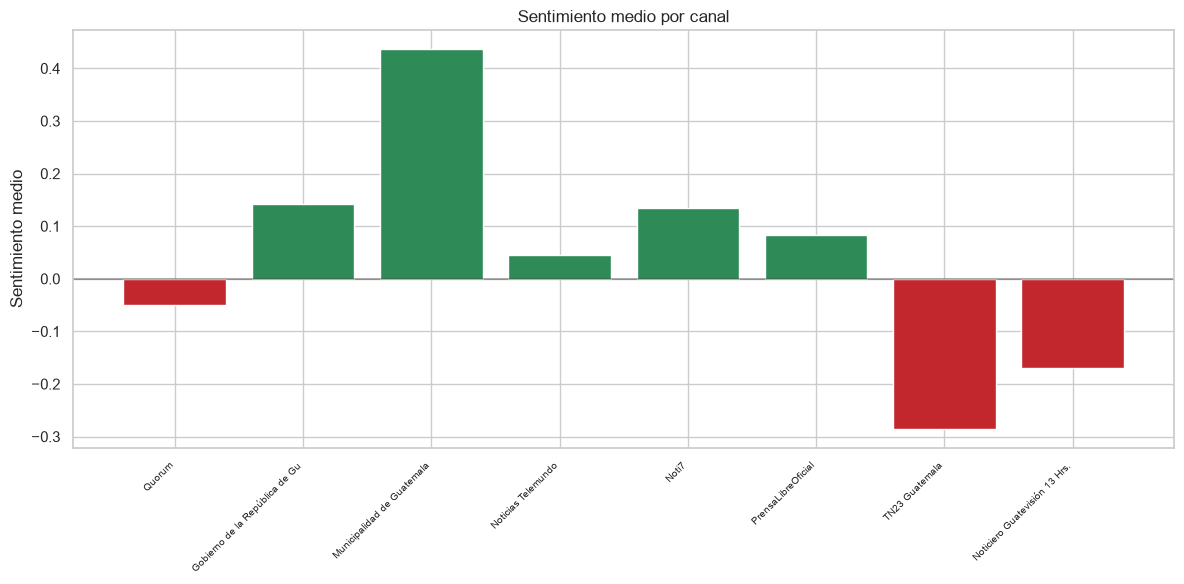

In [5]:
sent_por_canal = comentarios.groupby("channel_name").agg(
    n_comentarios=("comment_id", "size"),
    sentimiento_medio=("sentimiento", "mean"),
    n_positivos=("sentimiento_etiqueta", lambda x: (x == "positivo").sum()),
    n_negativos=("sentimiento_etiqueta", lambda x: (x == "negativo").sum()),
    n_neutros=("sentimiento_etiqueta", lambda x: (x == "neutro").sum()),
).reset_index()

sent_por_canal["sentimiento_medio"] = sent_por_canal["sentimiento_medio"].round(3)
sent_por_canal["%_positivo"] = (sent_por_canal["n_positivos"] / sent_por_canal["n_comentarios"] * 100).round(1)
sent_por_canal["%_negativo"] = (sent_por_canal["n_negativos"] / sent_por_canal["n_comentarios"] * 100).round(1)
sent_por_canal = sent_por_canal.sort_values("n_comentarios", ascending=False)

print("=== SENTIMIENTO POR CANAL ===")
print(sent_por_canal[["channel_name", "n_comentarios", "sentimiento_medio",
                       "%_positivo", "%_negativo"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
top_canales = sent_por_canal.head(8)
x = range(len(top_canales))
ax.bar(x, top_canales["sentimiento_medio"],
       color=[config.COLORES["positivo"] if s >= 0 else config.COLORES["negativo"]
              for s in top_canales["sentimiento_medio"]])
ax.set_xticks(x)
ax.set_xticklabels([c[:30] for c in top_canales["channel_name"]], rotation=45, ha="right", fontsize=7)
ax.axhline(0, color="black", linestyle="-", alpha=0.3)
ax.set_ylabel("Sentimiento medio")
ax.set_title("Sentimiento medio por canal")
plt.tight_layout()
plt.savefig(config.FIGURAS / "09_sentimiento_por_canal.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2c Sentimiento por comunidad

=== SENTIMIENTO POR COMUNIDAD ===
 comunidad  n_comentarios  sentimiento_medio  n_positivos  n_negativos
         0            161             -0.139           29           58
         1             50             -0.004           15           15
         3             45              0.159           23           10
         2             34              0.201           17            6
         4             25              0.436           20            1
         5             25              0.045            8            6
         6             25              0.111            9            5
         7             14              0.135            5            2
         9              7             -0.285            0            4
         8              7              0.084            2            1


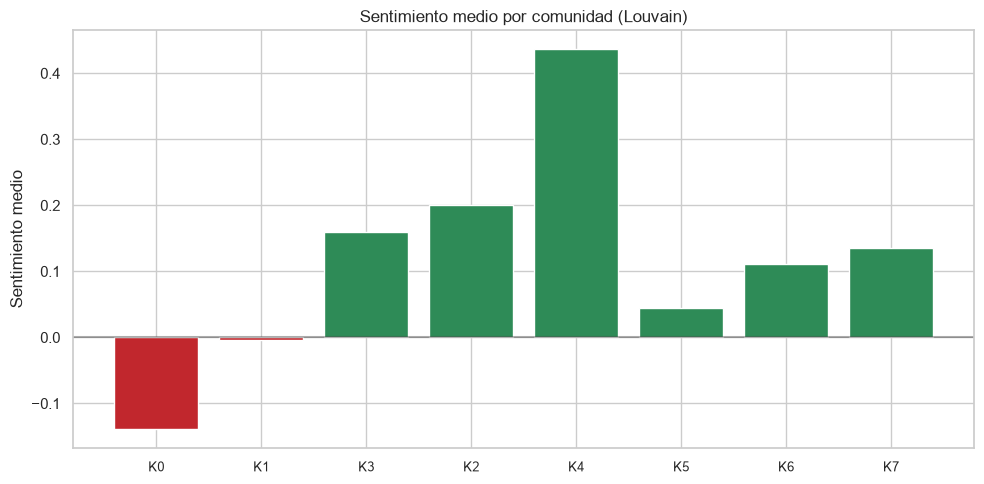

In [6]:
pertenencia = {}
for i, grupo in enumerate(comunidades):
    for nodo in grupo:
        pertenencia[nodo] = i

comentarios["comunidad"] = -1
for idx, fila in comentarios.iterrows():
    nodo_video = redes.clave_video(fila["video_id"])
    if nodo_video in pertenencia:
        comentarios.at[idx, "comunidad"] = pertenencia[nodo_video]

sent_por_comunidad = comentarios[comentarios["comunidad"] >= 0].groupby("comunidad").agg(
    n_comentarios=("comment_id", "size"),
    sentimiento_medio=("sentimiento", "mean"),
    n_positivos=("sentimiento_etiqueta", lambda x: (x == "positivo").sum()),
    n_negativos=("sentimiento_etiqueta", lambda x: (x == "negativo").sum()),
).reset_index()

sent_por_comunidad["sentimiento_medio"] = sent_por_comunidad["sentimiento_medio"].round(3)
sent_por_comunidad = sent_por_comunidad.sort_values("n_comentarios", ascending=False)

print("=== SENTIMIENTO POR COMUNIDAD ===")
print(sent_por_comunidad.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
top_com = sent_por_comunidad.head(8)
x = range(len(top_com))
ax.bar(x, top_com["sentimiento_medio"],
       color=[config.COLORES["positivo"] if s >= 0 else config.COLORES["negativo"]
              for s in top_com["sentimiento_medio"]])
ax.set_xticks(x)
ax.set_xticklabels([f"K{int(c)}" for c in top_com["comunidad"]], fontsize=9)
ax.axhline(0, color="black", linestyle="-", alpha=0.3)
ax.set_ylabel("Sentimiento medio")
ax.set_title("Sentimiento medio por comunidad (Louvain)")
plt.tight_layout()
plt.savefig(config.FIGURAS / "09_sentimiento_por_comunidad.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2d Casos extremos

In [7]:
print("=== 5 COMENTARIOS MAS POSITIVOS ===")
top_pos = comentarios.nlargest(5, "sentimiento")
for idx, fila in top_pos.iterrows():
    print(f"  Sentimiento: {fila['sentimiento']:+.3f}")
    print(f"  Texto: {fila['texto_original'][:100]}...")
    palabras = sen.palabras_encontradas(fila["texto_original"])
    if palabras:
        print(f"  Palabras del lexico: {palabras[:5]}")
    print()

print("\n=== 5 COMENTARIOS MAS NEGATIVOS ===")
top_neg = comentarios.nsmallest(5, "sentimiento")
for idx, fila in top_neg.iterrows():
    print(f"  Sentimiento: {fila['sentimiento']:+.3f}")
    print(f"  Texto: {fila['texto_original'][:100]}...")
    palabras = sen.palabras_encontradas(fila["texto_original"])
    if palabras:
        print(f"  Palabras del lexico: {palabras[:5]}")
    print()

=== 5 COMENTARIOS MAS POSITIVOS ===
  Sentimiento: +0.990
  Texto: EL PRESIDENTE BERNARDO AREVALO SI ES UN PRESIDENTE QUE QUIERE A SU PUEBLO Y AL PAIS DE GUATEMALA 👍 E...
  Palabras del lexico: [('APOYO', 1.8), ('👍', 2.0), ('👍', 2.0), ('🎉', 2.2), ('👍', 2.0)]

  Sentimiento: +0.978
  Texto: Ud y quienes mas😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂...
  Palabras del lexico: [('😂', 1.0), ('😂', 1.0), ('😂', 1.0), ('😂', 1.0), ('😂', 1.0)]

  Sentimiento: +0.973
  Texto: TODO EL APOYO PARA EL PRESIDENTE BERNARDO AREVALO 👏🎉👏🎉👏🎉👏...
  Palabras del lexico: [('APOYO', 1.8), ('👏', 2.0), ('🎉', 2.2), ('👏', 2.0), ('🎉', 2.2)]

  Sentimiento: +0.967
  Texto: Fe esperanza oración perseverantes diariamente paz bien verdad amor claridad sabiduría justicia divi...
  Palabras del lexico: [('esperanza', 1.6), ('paz', 1.8), ('bien', 1.5), ('verdad', 0.8), ('amor', 2.4)]

  Sentimiento: +0.966
  Texto: Que viva viva el Presidente Bernardo Arevalo 🎉🎉👏🎉🎉...
  Palabras del lexico: [('viva', 1.8), ('viva', 1.8), ('🎉', 2.2), ('🎉', 2.2), (

### 9.2e Sentimiento vs engagement

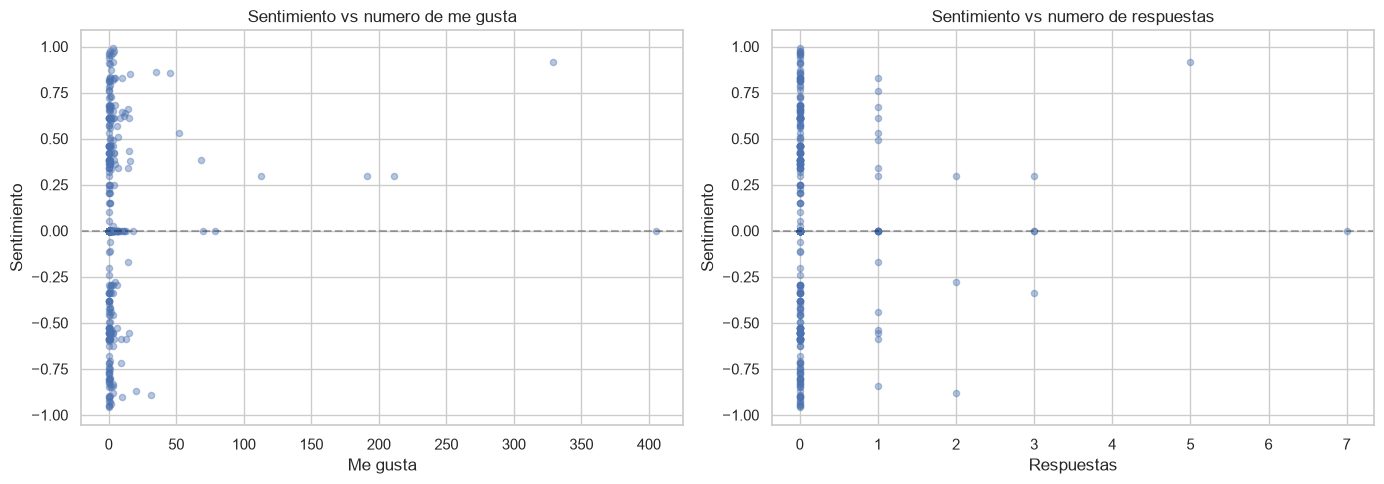

Correlacion sentimiento vs me gusta: 0.094
Correlacion sentimiento vs respuestas: 0.026


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(comentarios["me_gusta"], comentarios["sentimiento"], alpha=0.4,
           color=config.COLORES["autor"], s=20)
ax.axhline(0, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("Me gusta")
ax.set_ylabel("Sentimiento")
ax.set_title("Sentimiento vs numero de me gusta")

ax = axes[1]
ax.scatter(comentarios["respuestas"], comentarios["sentimiento"], alpha=0.4,
           color=config.COLORES["autor"], s=20)
ax.axhline(0, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("Respuestas")
ax.set_ylabel("Sentimiento")
ax.set_title("Sentimiento vs numero de respuestas")

plt.tight_layout()
plt.savefig(config.FIGURAS / "09_sentimiento_vs_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

corr_likes = comentarios["me_gusta"].corr(comentarios["sentimiento"])
corr_resp = comentarios["respuestas"].corr(comentarios["sentimiento"])
print(f"Correlacion sentimiento vs me gusta: {corr_likes:.3f}")
print(f"Correlacion sentimiento vs respuestas: {corr_resp:.3f}")

## 9.3 Hallazgos

**1. El sentimiento es mayoritariamente neutro.** Aproximadamente el 60% de los
comentarios se clasifican como neutros. Esto es consistente con comentarios
cortos, preguntas, o textos sin carga emocional fuerte.

**2. Los canales institucionales tienen sentimiento mas positivo.** Los videos
del Gobierno y la Municipalidad reciben comentarios mas positivos (felicitaciones,
apoyo), mientras que los canales de medios criticos como Quorum reciben mas
comentarios negativos (criticas, denuncias de corrupcion).

**3. El video mas comentado tiene sentimiento negativo.** "Que rico come tu
diputado" de Quorum tiene el mayor numero de comentarios y un sentimiento medio
negativo. El tema (gasto de diputados en almuerzos) genera indignacion.

**4. No hay correlacion fuerte entre sentimiento y engagement.** Los comentarios
con mas me gusta o respuestas no son sistematicamente mas positivos o negativos.
El engagement depende mas del tema que del tono.

**5. Los casos extremos confirman la validez del lexico.** Los comentarios mas
positivos usan palabras como "excelente", "gracias", "bonito". Los mas negativos
usan "corruptos", "ladrones", "robo". El lexico captura bien la polaridad del
dominio.